### imports

In [3]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import math

### Parameters

In [4]:
m = 10
mean_service_time = 8
mean_interarrival_time = 1
t_service_rate = 1/mean_service_time
interArrival_rate = 1/mean_interarrival_time

A = mean_interarrival_time * mean_service_time

n_repetitions = 10
n_customers = 10000

[  10.   97.  411. 1054. 2174. 3437. 4538. 5127. 5056. 4523. 3573.]
[0.00033333 0.00323333 0.0137     0.03513333 0.07246667 0.11456667
 0.15126667 0.1709     0.16853333 0.15076667 0.1191    ]


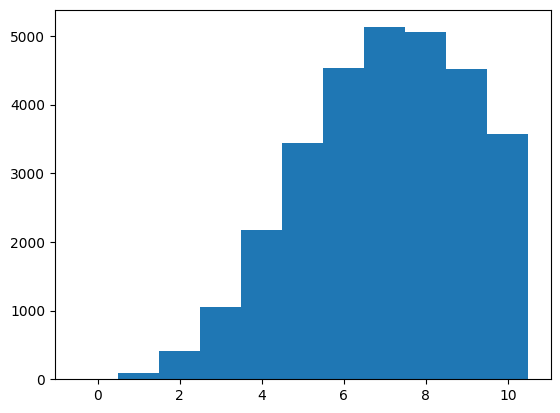

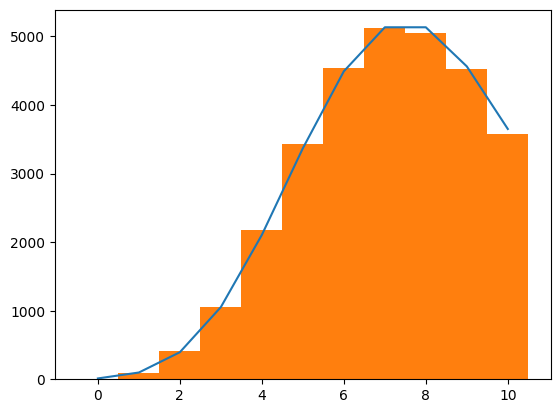

e: [  12.33491124   98.67928996  394.71715983 1052.57909289 2105.15818577
 3368.25309724 4491.00412965 5132.57614817 5132.57614817 4562.28990949
 3649.83192759]
1.0
chi2: 0.5903505917267784


In [5]:
def g(i):
    return (A**i)/math.factorial(i)

def h1(x, m = 10):
    choice =  np.random.uniform(0,1)
    choice =  choice < 0.5 
    if (x == 0):
        if choice:
            return 0
        else:
            return 1
        
    elif (x == m):
        if choice:
            return m
        else:
            return m-1
    
    else:
        if choice:
            return x-1
        else:
            return x+1


def a(x,y):
    res = min(1,g(y)/g(x))
    return res



def generate_sample( sample_size, start_value = 0, burn_in = 0, h = h1):
    x = start_value
    result = []
    
    for _ in range(burn_in):
        y = h(x)
        accept_rate = a(x,y)
        choice = np.random.uniform(0,1)

        if choice <= accept_rate:
            x = y


    for _ in range(sample_size):
        y = h(x)
        accept_rate = a(x,y)
        choice = np.random.uniform(0,1)

        if choice <= accept_rate:
            result.append(y)
            x = y
        else:
            result.append(x)

    return result

data_size = 30000
data = np.array(generate_sample(data_size,burn_in=int(data_size/2)))

observed,buckets,_ = plt.hist(data,bins=[-0.5+i for i in range(0,m+2)])


print(observed)

observed_norm = np.array(observed) / sum(observed)
print(observed_norm)
plt.show()
'''
plt.hist(observed_norm,bins=[-0.5+i for i in range(0,m+2)])
g_data = np.array([g(i) for i in range(m+1)])
g_norm = g_data/max(g_data)
plt.plot(g_norm)

plt.show()

c = max(g_norm) / max(data)
print(c)
plt.plot(g_data*c)
plt.hist(data)
plt.show()

'''

p_ = np.array([8**i/math.factorial(i) for i in range(0,m+1)])
p_ /= p_.sum()

e = data_size*p_
plt.plot(e)
plt.hist(data,bins=[-0.5+i for i in range(0,m+2)])
plt.show()
print("e:",e)
print(p_.sum())

T = 0
for i in range(len(e)):
    T += (observed[i]-e[i])**2/e[i]

chi = 1- stats.chi2.cdf(T,len(observed)-1)
print("chi2:",chi)

In [6]:

def generate_thinned_sample( sample_size, start_value = 0, burn_in = 0,thinning = 40,h=h1):
    x = start_value
    result = []
    
    for _ in range(burn_in):
        y = h(x)
        accept_rate = a(x,y)
        choice = np.random.uniform(0,1)

        if choice <= accept_rate:
            x = y


    for _ in range(sample_size):
        y = h(x)
        accept_rate = a(x,y)
        choice = np.random.uniform(0,1)

        if choice <= accept_rate:
            result.append(y)
            x = y
        else:
            result.append(x)
        
        for _ in range(thinning):
            y = h(x)
            accept_rate = a(x,y)
            choice = np.random.uniform(0,1)

            if choice <= accept_rate:
                x = y

    return result


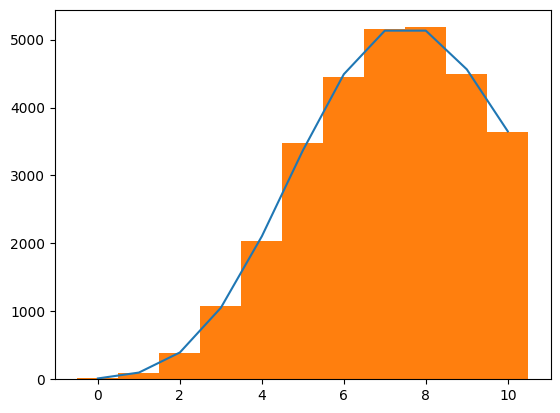

e: [  12.33491124   98.67928996  394.71715983 1052.57909289 2105.15818577
 3368.25309724 4491.00412965 5132.57614817 5132.57614817 4562.28990949
 3649.83192759]
1.0
chi2: 0.5369149386505707


In [7]:
thinned_data = generate_thinned_sample(data_size)
p_ = np.array([8**i/math.factorial(i) for i in range(0,m+1)])
p_ /= p_.sum()

e = data_size*p_
plt.plot(e)
thinned_observed,_,_ = plt.hist(thinned_data,bins=[-0.5+i for i in range(0,m+2)])

plt.show()
print("e:",e)
print(p_.sum())

T = 0
for i in range(len(e)):
    T += (thinned_observed[i]-e[i])**2/e[i]

chi = 1- stats.chi2.cdf(T,len(thinned_observed)-1)
print("chi2:",chi)

### part 2

### Defining parameters

In [12]:
# Parameters for Exercise 6 Part 2
A_1 = 4
A_2 = 4
m = 10
sample_size = 10000
burn_in = 1000
thinning = 20

### direct MH

In [9]:
def g(i,j):
    return (A_1**i/math.factorial(i)) * ( A_2**j/math.factorial(j) )


valid_states = []

for i in range(m + 1):
    for j in range(m + 1 - i):
        valid_states.append((i, j))


def h2(x, y):
    index = np.random.randint(0, len(valid_states))
    return valid_states[index]


def a(i_prev,j_prev,i_new,j_new):
    res = min(1,g(i_new,j_new)/g(i_prev,j_prev))
    return res



def generate_thinned_sample_direct( sample_size, start_value_i = 0, start_value_j=0, burn_in = 0,thinning = 40,h = h2):
    cur_i = start_value_i
    cur_j = start_value_j

    result = []
    
    for _ in range(burn_in):
        new_i,new_j = h(cur_i,cur_j)

        accept_rate = a(cur_i,cur_j,new_i,new_j)

        choice = np.random.uniform(0,1)

        if choice <= accept_rate:
            cur_i = new_i
            cur_j = new_j


    for _ in range(sample_size):
        new_i,new_j = h(cur_i,cur_j)

        accept_rate = a(cur_i,cur_j,new_i,new_j)

        choice = np.random.uniform(0,1)

        if choice <= accept_rate:
            result.append((new_i,new_j))
            cur_i = new_i
            cur_j = new_j

        else:
            result.append((cur_i,cur_j))
        
        for _ in range(thinning):
            new_i,new_j = h(cur_i,cur_j)

            accept_rate = a(cur_i,cur_j,new_i,new_j)
            choice = np.random.uniform(0,1)

            if choice <= accept_rate:
                cur_i = new_i
                cur_j = new_j

    return result






### Coordinate-wise

In [10]:
def h3(changed_coord, unchanged_coord, m=10):
    upper = m - unchanged_coord

    if upper == 0:
        return 0

    choice = np.random.uniform(0, 1)

    if changed_coord == 0:
        if choice < 0.5:
            return 0
        else:
            return 1

    elif changed_coord == upper:
        if choice < 0.5:
            return upper
        else:
            return upper - 1

    else:
        if choice < 0.5:
            return changed_coord - 1
        else:
            return changed_coord + 1



def generate_thinned_sample_coordinate_wise( sample_size, start_value_i = 0, start_value_j=0, burn_in = 0,thinning = 40,h = h3):
    cur_i = start_value_i
    cur_j = start_value_j

    result = []
    
    for _ in range(burn_in):
        new_i= h(cur_i,cur_j)

        accept_rate = a(cur_i,cur_j,new_i,cur_j)

        choice = np.random.uniform(0,1)

        if choice <= accept_rate:
            cur_i = new_i

        new_j= h(cur_j,cur_i)
        accept_rate = a(cur_i,cur_j,cur_i,new_j)

        choice = np.random.uniform(0,1)
        if choice <= accept_rate:
            cur_j = new_j


    for _ in range(sample_size):
        new_i= h(cur_i,cur_j)

        accept_rate = a(cur_i,cur_j,new_i,cur_j)

        choice = np.random.uniform(0,1)

        if choice <= accept_rate:
            cur_i = new_i

        new_j= h(cur_j,cur_i)
        accept_rate = a(cur_i,cur_j,cur_i,new_j)

        choice = np.random.uniform(0,1)
        if choice <= accept_rate:
            cur_j = new_j

        result.append((cur_i,cur_j))


        for _ in range(thinning):
            new_i= h(cur_i,cur_j)

            accept_rate = a(cur_i,cur_j,new_i,cur_j)

            choice = np.random.uniform(0,1)

            if choice <= accept_rate:
                cur_i = new_i

            new_j= h(cur_j,cur_i)
            accept_rate = a(cur_i,cur_j,cur_i,new_j)

            choice = np.random.uniform(0,1)
            if choice <= accept_rate:
                cur_j = new_j

    return result







### Gibbs

In [11]:
def sample_conditional(max_value, A):
    weights = np.array([A**k / math.factorial(k) for k in range(max_value + 1)])
    probabilities = weights / weights.sum()

    return np.random.choice(np.arange(max_value + 1), p=probabilities)


def generate_thinned_sample_gibbs(sample_size, start_value_i=0, start_value_j=0, burn_in=0, thinning=40):
    i = start_value_i
    j = start_value_j

    result = []

    for _ in range(burn_in):
        i = sample_conditional(m - j, A_1)
        j = sample_conditional(m - i, A_2)

    for _ in range(sample_size):
        i = sample_conditional(m - j, A_1)
        j = sample_conditional(m - i, A_2)

        result.append((i, j))

        for _ in range(thinning):
            i = sample_conditional(m - j, A_1)
            j = sample_conditional(m - i, A_2)

    return result

### Running the generators

#### Setup

In [15]:
def get_valid_states(m):
    states = []
    for i in range(m + 1):
        for j in range(m + 1 - i):
            states.append((i, j))
    return states


valid_states = get_valid_states(m)


def theoretical_probabilities_2d():
    weights = []

    for i, j in valid_states:
        weight = (A_1**i / math.factorial(i)) * (A_2**j / math.factorial(j))
        weights.append(weight)

    weights = np.array(weights)
    probabilities = weights / weights.sum()

    return probabilities


theory_probs = theoretical_probabilities_2d()

def observed_counts_2d(samples):
    counts = []

    for state in valid_states:
        counts.append(samples.count(state))

    return np.array(counts)

def chi_square_test_2d(samples):
    observed = observed_counts_2d(samples)
    expected = sample_size * theory_probs

    T = np.sum((observed - expected)**2 / expected)

    df = len(valid_states) - 1
    p_value = stats.chi2.sf(T, df)

    return T, p_value

In [16]:
direct_samples = generate_thinned_sample_direct(
    sample_size=sample_size,
    start_value_i=0,
    start_value_j=0,
    burn_in=burn_in,
    thinning=thinning
)

T_direct, p_direct = chi_square_test_2d(direct_samples)

print("Direct Metropolis-Hastings")
print("Chi-square statistic:", T_direct)
print("p-value:", p_direct)
print()

Direct Metropolis-Hastings
Chi-square statistic: 81.1795075166713
p-value: 0.084831215971499



In [18]:
coordinate_samples = generate_thinned_sample_coordinate_wise(
    sample_size=sample_size,
    start_value_i=0,
    start_value_j=0,
    burn_in=burn_in,
    thinning=thinning
)

T_coordinate, p_coordinate = chi_square_test_2d(coordinate_samples)

print("Coordinatewise Metropolis-Hastings")
print("Chi-square statistic:", T_coordinate)
print("p-value:", p_coordinate)
print()

Coordinatewise Metropolis-Hastings
Chi-square statistic: 51.39190780146911
p-value: 0.8904885729927177



In [19]:
gibbs_samples = generate_thinned_sample_gibbs(
    sample_size=sample_size,
    start_value_i=0,
    start_value_j=0,
    burn_in=burn_in,
    thinning=thinning
)

T_gibbs, p_gibbs = chi_square_test_2d(gibbs_samples)

print("Gibbs sampling")
print("Chi-square statistic:", T_gibbs)
print("p-value:", p_gibbs)
print()

Gibbs sampling
Chi-square statistic: 61.79586171714761
p-value: 0.5897960272333603



### Comparisons

In [20]:
def print_comparison(samples, method_name, max_rows=15):
    observed = observed_counts_2d(samples)
    observed_probs = observed / len(samples)

    print(method_name)
    print("state | observed probability | theoretical probability")
    print("-" * 55)

    for index in range(min(max_rows, len(valid_states))):
        state = valid_states[index]
        print(state, observed_probs[index], theory_probs[index])

    print()

In [21]:
print_comparison(direct_samples, "Direct Metropolis-Hastings")
print_comparison(coordinate_samples, "Coordinatewise Metropolis-Hastings")
print_comparison(gibbs_samples, "Gibbs sampling")

Direct Metropolis-Hastings
state | observed probability | theoretical probability
-------------------------------------------------------
(0, 0) 0.0008 0.00041116370815887153
(0, 1) 0.0018 0.0016446548326354861
(0, 2) 0.0029 0.0032893096652709722
(0, 3) 0.0041 0.004385746220361296
(0, 4) 0.0047 0.004385746220361296
(0, 5) 0.0031 0.003508596976289037
(0, 6) 0.0023 0.0023390646508593582
(0, 7) 0.0013 0.001336608371919633
(0, 8) 0.0008 0.0006683041859598165
(0, 9) 0.0004 0.0002970240826488074
(0, 10) 0.0 0.00011880963305952294
(1, 0) 0.0021 0.0016446548326354861
(1, 1) 0.0069 0.0065786193305419445
(1, 2) 0.0144 0.013157238661083889
(1, 3) 0.0158 0.017542984881445185

Coordinatewise Metropolis-Hastings
state | observed probability | theoretical probability
-------------------------------------------------------
(0, 0) 0.0005 0.00041116370815887153
(0, 1) 0.0014 0.0016446548326354861
(0, 2) 0.0035 0.0032893096652709722
(0, 3) 0.0037 0.004385746220361296
(0, 4) 0.0049 0.004385746220361296
(0

### Summary stats

In [22]:
print("Summary")
print("Method                         Chi-square statistic     p-value")
print("-" * 65)
print("Direct MH                     ", T_direct, p_direct)
print("Coordinatewise MH             ", T_coordinate, p_coordinate)
print("Gibbs                         ", T_gibbs, p_gibbs)

Summary
Method                         Chi-square statistic     p-value
-----------------------------------------------------------------
Direct MH                      81.1795075166713 0.084831215971499
Coordinatewise MH              51.39190780146911 0.8904885729927177
Gibbs                          61.79586171714761 0.5897960272333603


## Part 3

### a

In [23]:
rho = 0.5

cov = np.array([
    [1, rho],
    [rho, 1]
])

In [24]:
def generate_prior_sample(rho=0.5):
    mean = np.array([0, 0])
    cov = np.array([
        [1, rho],
        [rho, 1]
    ])

    xi, gamma = np.random.multivariate_normal(mean, cov)

    theta = np.exp(xi)
    psi = np.exp(gamma)

    return theta, psi, xi, gamma

In [25]:
theta_true, psi_true, xi_true, gamma_true = generate_prior_sample()

print("xi:", xi_true)
print("gamma:", gamma_true)
print("theta:", theta_true)
print("psi:", psi_true)

xi: -1.0620047432960134
gamma: -0.5577146202398415
theta: 0.34576195110413394
psi: 0.5725159863204027


#### b

In [26]:
def simulate_observations(theta, psi, n=10):
    return np.random.normal(loc=theta, scale=np.sqrt(psi), size=n)

In [27]:
n = 10

X = simulate_observations(theta_true, psi_true, n)

print("X:", X)
print("sample mean:", np.mean(X))
print("sample variance:", np.var(X, ddof=1))

X: [ 0.0601463  -0.16337361  1.62729037  0.93415133 -0.82750458 -0.46922252
  0.32887859 -0.72304586  0.82727834  0.47405314]
sample mean: 0.20686515125547542
sample variance: 0.6186772396826253


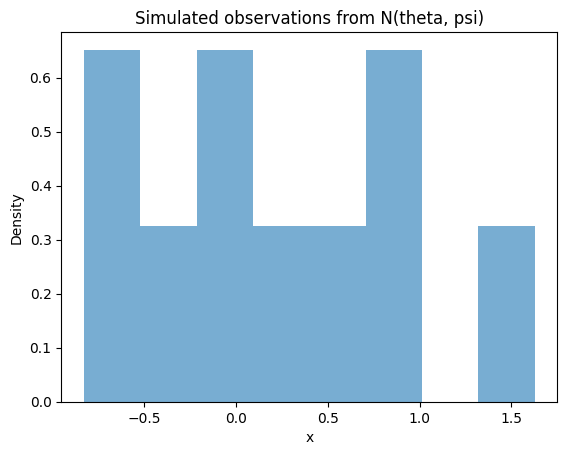

In [28]:
plt.hist(X, bins=8, density=True, alpha=0.6)
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Simulated observations from N(theta, psi)")
plt.show()

#### c

In [29]:
def log_prior(theta, psi, rho=0.5):
    if theta <= 0 or psi <= 0:
        return -np.inf

    xi = np.log(theta)
    gamma = np.log(psi)

    log_density = (
        -np.log(theta)
        -np.log(psi)
        -0.5 * np.log(1 - rho**2)
        - (
            xi**2 - 2*rho*xi*gamma + gamma**2
        ) / (2 * (1 - rho**2))
    )

    return log_density


def log_likelihood(theta, psi, data):
    if theta <= 0 or psi <= 0:
        return -np.inf

    n = len(data)

    log_density = (
        -n/2 * np.log(psi)
        -np.sum((data - theta)**2) / (2 * psi)
    )

    return log_density


def log_posterior(theta, psi, data, rho=0.5):
    return log_likelihood(theta, psi, data) + log_prior(theta, psi, rho)

#### d

In [30]:
def log_posterior_xi_gamma(xi, gamma, data, rho=0.5):
    theta = np.exp(xi)
    psi = np.exp(gamma)

    return log_posterior(theta, psi, data, rho)

In [31]:
def metropolis_posterior(data, iterations=20000, burn_in=5000, proposal_sd=0.2):
    xi = 0
    gamma = 0

    samples = []
    accepted = 0

    current_log_post = log_posterior_xi_gamma(xi, gamma, data)

    for t in range(iterations):
        xi_new = xi + np.random.normal(0, proposal_sd)
        gamma_new = gamma + np.random.normal(0, proposal_sd)

        new_log_post = log_posterior_xi_gamma(xi_new, gamma_new, data)

        log_acceptance = new_log_post - current_log_post

        if np.log(np.random.uniform(0, 1)) < log_acceptance:
            xi = xi_new
            gamma = gamma_new
            current_log_post = new_log_post
            accepted += 1

        if t >= burn_in:
            theta = np.exp(xi)
            psi = np.exp(gamma)
            samples.append((theta, psi))

    samples = np.array(samples)
    acceptance_rate = accepted / iterations

    return samples, acceptance_rate

In [32]:
posterior_samples_10, acc_rate_10 = metropolis_posterior(
    X,
    iterations=20000,
    burn_in=5000,
    proposal_sd=0.2
)

print("Acceptance rate:", acc_rate_10)

theta_samples_10 = posterior_samples_10[:, 0]
psi_samples_10 = posterior_samples_10[:, 1]

print("Posterior mean theta:", np.mean(theta_samples_10))
print("Posterior mean psi:", np.mean(psi_samples_10))

print("True theta:", theta_true)
print("True psi:", psi_true)

Acceptance rate: 0.77915
Posterior mean theta: 0.2554553231294964
Posterior mean psi: 0.5523839576514551
True theta: 0.34576195110413394
True psi: 0.5725159863204027


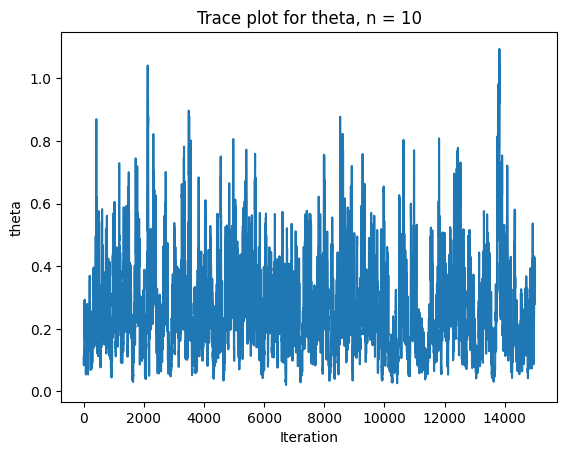

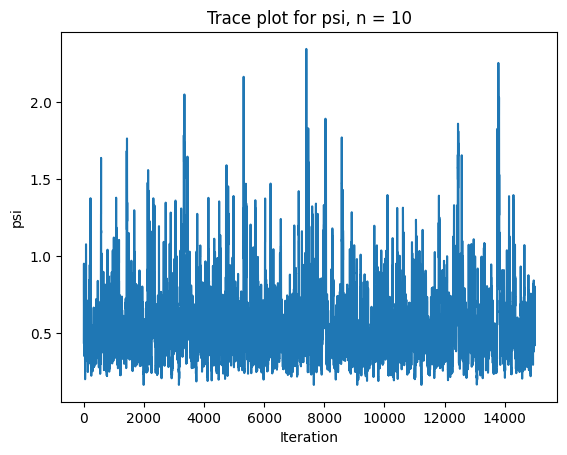

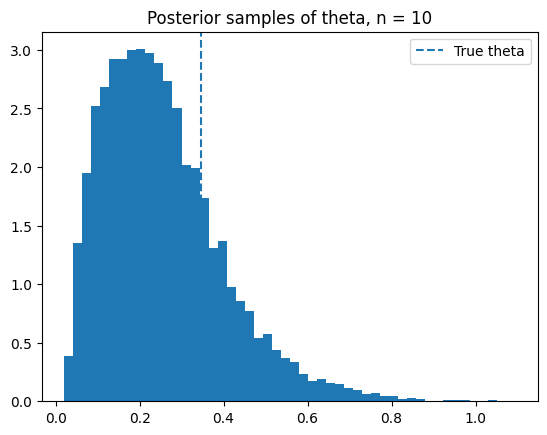

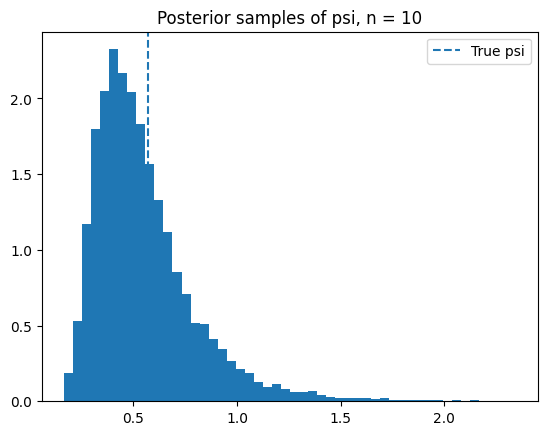

In [33]:
plt.plot(theta_samples_10)
plt.title("Trace plot for theta, n = 10")
plt.xlabel("Iteration")
plt.ylabel("theta")
plt.show()

plt.plot(psi_samples_10)
plt.title("Trace plot for psi, n = 10")
plt.xlabel("Iteration")
plt.ylabel("psi")
plt.show()

plt.hist(theta_samples_10, bins=50, density=True)
plt.axvline(theta_true, linestyle="--", label="True theta")
plt.title("Posterior samples of theta, n = 10")
plt.legend()
plt.show()

plt.hist(psi_samples_10, bins=50, density=True)
plt.axvline(psi_true, linestyle="--", label="True psi")
plt.title("Posterior samples of psi, n = 10")
plt.legend()
plt.show()

#### e

In [34]:
X_100 = simulate_observations(theta_true, psi_true, n=100)
X_1000 = simulate_observations(theta_true, psi_true, n=1000)

In [35]:
posterior_samples_100, acc_rate_100 = metropolis_posterior(
    X_100,
    iterations=20000,
    burn_in=5000,
    proposal_sd=0.1
)

posterior_samples_1000, acc_rate_1000 = metropolis_posterior(
    X_1000,
    iterations=20000,
    burn_in=5000,
    proposal_sd=0.05
)

print("Acceptance rate n=100:", acc_rate_100)
print("Acceptance rate n=1000:", acc_rate_1000)

Acceptance rate n=100: 0.7071
Acceptance rate n=1000: 0.58025


In [36]:
def summarize_posterior(samples, true_theta, true_psi, label):
    theta_samples = samples[:, 0]
    psi_samples = samples[:, 1]

    print(label)
    print("Posterior mean theta:", np.mean(theta_samples))
    print("Posterior mean psi:", np.mean(psi_samples))
    print("Posterior sd theta:", np.std(theta_samples, ddof=1))
    print("Posterior sd psi:", np.std(psi_samples, ddof=1))
    print("True theta:", true_theta)
    print("True psi:", true_psi)
    print()


summarize_posterior(posterior_samples_10, theta_true, psi_true, "n = 10")
summarize_posterior(posterior_samples_100, theta_true, psi_true, "n = 100")
summarize_posterior(posterior_samples_1000, theta_true, psi_true, "n = 1000")

n = 10
Posterior mean theta: 0.2554553231294964
Posterior mean psi: 0.5523839576514551
Posterior sd theta: 0.14367266095771944
Posterior sd psi: 0.24756096415810583
True theta: 0.34576195110413394
True psi: 0.5725159863204027

n = 100
Posterior mean theta: 0.3826793353997814
Posterior mean psi: 0.6700739564560346
Posterior sd theta: 0.07872059150998652
Posterior sd psi: 0.09238180617574161
True theta: 0.34576195110413394
True psi: 0.5725159863204027

n = 1000
Posterior mean theta: 0.3343763788731167
Posterior mean psi: 0.5559395678561156
Posterior sd theta: 0.024214287383863494
Posterior sd psi: 0.024123872603851924
True theta: 0.34576195110413394
True psi: 0.5725159863204027



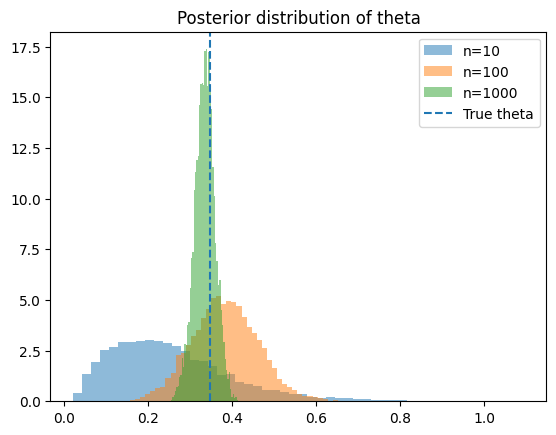

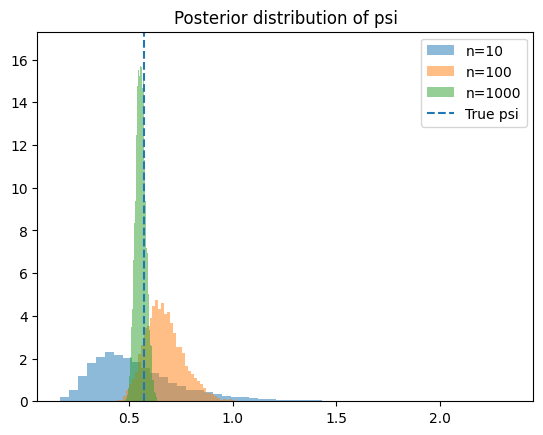

In [37]:
plt.hist(posterior_samples_10[:, 0], bins=50, density=True, alpha=0.5, label="n=10")
plt.hist(posterior_samples_100[:, 0], bins=50, density=True, alpha=0.5, label="n=100")
plt.hist(posterior_samples_1000[:, 0], bins=50, density=True, alpha=0.5, label="n=1000")
plt.axvline(theta_true, linestyle="--", label="True theta")
plt.title("Posterior distribution of theta")
plt.legend()
plt.show()

plt.hist(posterior_samples_10[:, 1], bins=50, density=True, alpha=0.5, label="n=10")
plt.hist(posterior_samples_100[:, 1], bins=50, density=True, alpha=0.5, label="n=100")
plt.hist(posterior_samples_1000[:, 1], bins=50, density=True, alpha=0.5, label="n=1000")
plt.axvline(psi_true, linestyle="--", label="True psi")
plt.title("Posterior distribution of psi")
plt.legend()
plt.show()